<a href="https://colab.research.google.com/github/sainiPriyan/pytorch/blob/main/02_pytorch_classification_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Classification with PyTorch

## 1. Making classification data and get it ready

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles

# Make 1000 samples

n_samples = 1000

X,y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)



In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [5]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                        "X2":X[:,1],
                        "label":y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


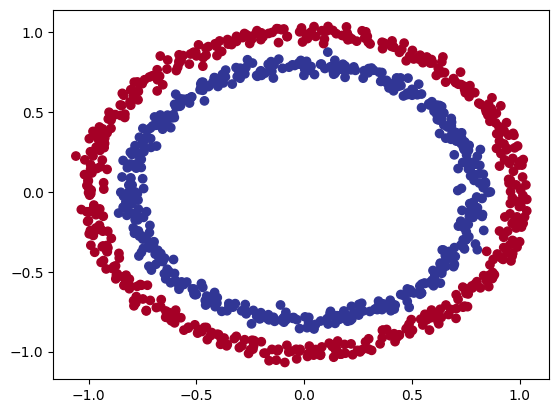

In [6]:
import matplotlib.pyplot as plt

plt.scatter(x = X[:,0],
            y = X[:,1],
            c= y,
            cmap = plt.cm.RdYlBu)

 Note: Toy Data set - a data set that is small enough to experiment on but large enough to practice the fundamentals

### check input and output shapes

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

### Turn Data in Tensors and create train and test splits

In [8]:
import torch
from torch import nn
import numpy as np

In [9]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:10],y[:10]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967],
         [-0.4796,  0.6764],
         [-0.0136,  0.8033],
         [ 0.7715,  0.1478],
         [-0.1693, -0.7935],
         [-0.1215,  1.0215]]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [11]:
len(X_train), len(X_test), len(y_train),len(y_test)

(800, 200, 800, 200)

## Building a model

1. Device agnostic code so our code will run on an accelerator (GPU) if avilable
2. Construct a model (by subclassing nn.Module)
3. Define a loss function and optimiser
4. Create a training and testing loop

In [12]:
import torch
from torch import nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [13]:
class CircleModel_0 (nn.Module):

  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(in_features=2,
                            out_features=5)
    self.layer2 = nn.Linear(in_features=5,
                            out_features=1)

    # self.two_linear_layers = nn.Sequential(
    #   nn.Linear(in_features=2, out_features=5),
    #   nn.Linear(in_features=5, out_features=1)
    # ).to(device)

  def forward(self,x):

    return (self.layer2(nn.ReLU()(self.layer1(x))))  # x -> layer1 -> layer2 -> output
    # return self.two_linear_layers(x)

model_0 = CircleModel_0().to(device)
model_0

CircleModel_0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [15]:
# Replication the model using nn.Sequential()

# model_0 = nn.Sequential(
#     nn.Linear(in_features=2, out_features=5),
#     nn.Linear(in_features=5, out_features=1)
# ).to(device)

In [16]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.6408, -0.1582],
                      [ 0.5890,  0.5777],
                      [ 0.4420,  0.0556],
                      [ 0.5596,  0.4353],
                      [-0.6346, -0.2296]], device='cuda:0')),
             ('layer1.bias',
              tensor([0.0882, 0.0160, 0.3573, 0.5525, 0.0260], device='cuda:0')),
             ('layer2.weight',
              tensor([[-0.3899, -0.0620,  0.0500, -0.0207, -0.3108]], device='cuda:0')),
             ('layer2.bias', tensor([0.4307], device='cuda:0'))])

In [17]:
with torch.inference_mode():
  untrained_preds = torch.round(model_0(X_test.to(device)))
len(untrained_preds), untrained_preds.shape,len(X_test),X_test.shape


(200, torch.Size([200, 1]), 200, torch.Size([200, 2]))

In [18]:
untrained_preds[:10], y_test[:10]

(tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.]], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### Setup loss function and optimiser

In [19]:
loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation function buildin

optimiser = torch.optim.SGD(params= model_0.parameters(),
                            lr = 0.01)


In [20]:
# Calculate accuracy

def accuracy_fn(y_pred, y_true):
  correct = torch.eq(y_pred,y_true).sum().item()
  return (correct/len(y_pred)) * 100

### Training Model

In [21]:
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5] # raw output of the model

In [22]:
y_logits

tensor([[0.3838],
        [0.3953],
        [0.2625],
        [0.4029],
        [0.2652]], device='cuda:0')

In [23]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5948],
        [0.5976],
        [0.5653],
        [0.5994],
        [0.5659]], device='cuda:0')

In [24]:
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))))

### Building the training and testing loops

In [25]:
!nvidia-smi

Tue Mar 10 09:29:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P0             28W /   70W |     153MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [26]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 10000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs+1):

  model_0.train()

# forward pass:

  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

# calculate loss/ accuracy

  loss = loss_fn(y_logits,
                 y_train)

  acc = accuracy_fn(y_true=y_train,
                    y_pred = y_pred)

# optimiser zero grad
  optimiser.zero_grad()

# backpropa
  loss.backward()

# optimiser step
  optimiser.step()


  model_0.eval()

  with torch.inference_mode():

    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true = y_test,
                          y_pred = test_pred)

    if epoch % 10 == 0:
      print(f'Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%')



Epoch: 0 | Loss: 0.69428 | Acc: 50.00% | Test Loss: 0.69612 | Test acc: 50.00%
Epoch: 10 | Loss: 0.69344 | Acc: 50.00% | Test Loss: 0.69520 | Test acc: 50.00%
Epoch: 20 | Loss: 0.69266 | Acc: 50.00% | Test Loss: 0.69435 | Test acc: 50.00%
Epoch: 30 | Loss: 0.69195 | Acc: 50.00% | Test Loss: 0.69356 | Test acc: 50.00%
Epoch: 40 | Loss: 0.69129 | Acc: 50.00% | Test Loss: 0.69284 | Test acc: 50.00%
Epoch: 50 | Loss: 0.69069 | Acc: 50.00% | Test Loss: 0.69218 | Test acc: 50.00%
Epoch: 60 | Loss: 0.69013 | Acc: 50.00% | Test Loss: 0.69156 | Test acc: 50.00%
Epoch: 70 | Loss: 0.68961 | Acc: 50.00% | Test Loss: 0.69100 | Test acc: 50.00%
Epoch: 80 | Loss: 0.68913 | Acc: 50.00% | Test Loss: 0.69048 | Test acc: 50.00%
Epoch: 90 | Loss: 0.68869 | Acc: 51.38% | Test Loss: 0.69000 | Test acc: 51.50%
Epoch: 100 | Loss: 0.68828 | Acc: 53.00% | Test Loss: 0.68955 | Test acc: 52.50%
Epoch: 110 | Loss: 0.68791 | Acc: 55.50% | Test Loss: 0.68914 | Test acc: 54.00%
Epoch: 120 | Loss: 0.68756 | Acc: 56.88

## Make predictions and evauate the model

In [27]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print('helper_functions.py already exists')

else:
  print('Download helper_functions.py')
  request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py')

  with open('helper_functions.py', 'wb') as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

Download helper_functions.py


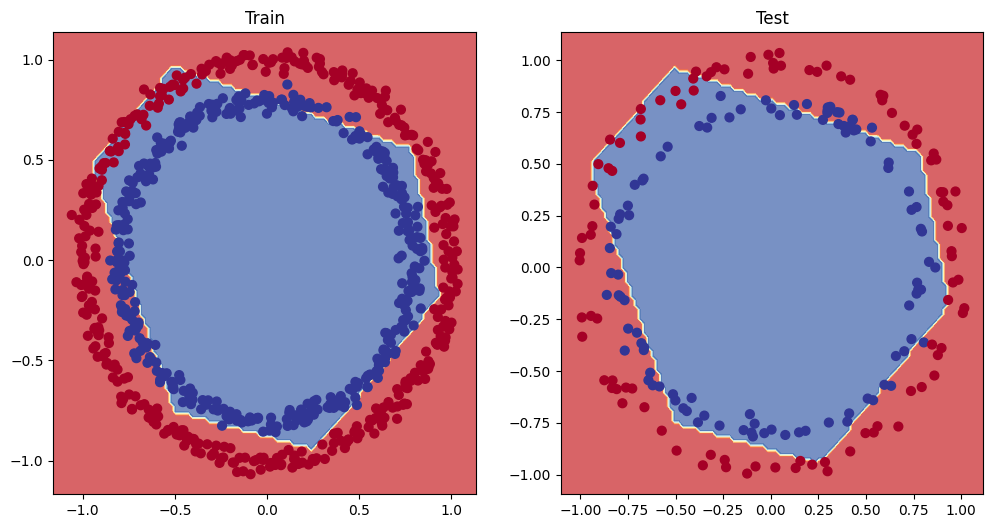

In [28]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)

## Improving a model:

* Add more layers
* Add more hidden units
* Fit for longer
* Changing the activation function
* Change the learning rate
* Change the loss function


In [29]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2, out_features= 10)
    self.layer_2  = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self,x):
    # z = self.layer_1(X)
    # z = self.layer_2(z)
    # z = self.layer_3(z)

    return self.layer_3( self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [30]:
loss_fn = nn.BCEWithLogitsLoss()

optimiser = torch.optim.SGD(params=model_1.parameters(),
                            lr = 0.1)

In [31]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs+1):

  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn( y_logits,y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  optimiser.zero_grad()

  loss.backward()

  optimiser.step()

  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()

    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)

    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  if epoch % 100 == 0:
    print(f'Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%')




Epoch: 0 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261 | Test acc: 51.00%
Epoch: 100 | Loss: 0.69305 | Acc: 50.38% | Test Loss: 0.69379 | Test acc: 48.00%
Epoch: 200 | Loss: 0.69299 | Acc: 51.12% | Test Loss: 0.69437 | Test acc: 46.00%
Epoch: 300 | Loss: 0.69298 | Acc: 51.62% | Test Loss: 0.69458 | Test acc: 45.00%
Epoch: 400 | Loss: 0.69298 | Acc: 51.12% | Test Loss: 0.69465 | Test acc: 46.00%
Epoch: 500 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69467 | Test acc: 46.00%
Epoch: 600 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69468 | Test acc: 46.00%
Epoch: 700 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69468 | Test acc: 46.00%
Epoch: 800 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69468 | Test acc: 46.00%
Epoch: 900 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69468 | Test acc: 46.00%
Epoch: 1000 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69468 | Test acc: 46.00%


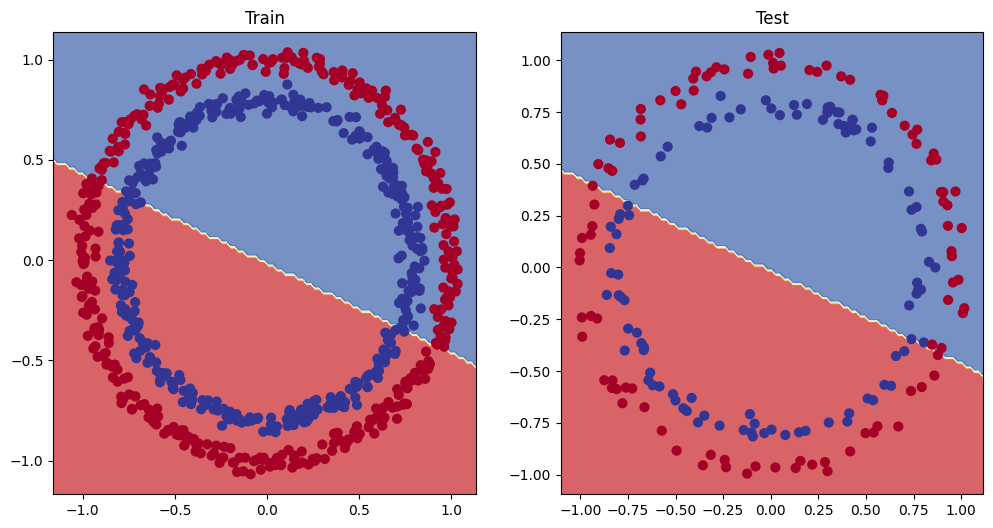

In [32]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

In [33]:
weight = 0.7
bias = 0.3

X_regression = torch.arange(0,1,0.01).unsqueeze(dim=1)
y_regression = weight * X_regression + bias


In [34]:
training_split = int(0.8*len(X_regression))

X_train_regression, y_train_regression = X_regression[:training_split],y_regression[:training_split]
X_test_regression, y_test_regression = X_regression[training_split:],y_regression[training_split:]

In [35]:
len(X_test_regression), len(X_train_regression)

(20, 80)

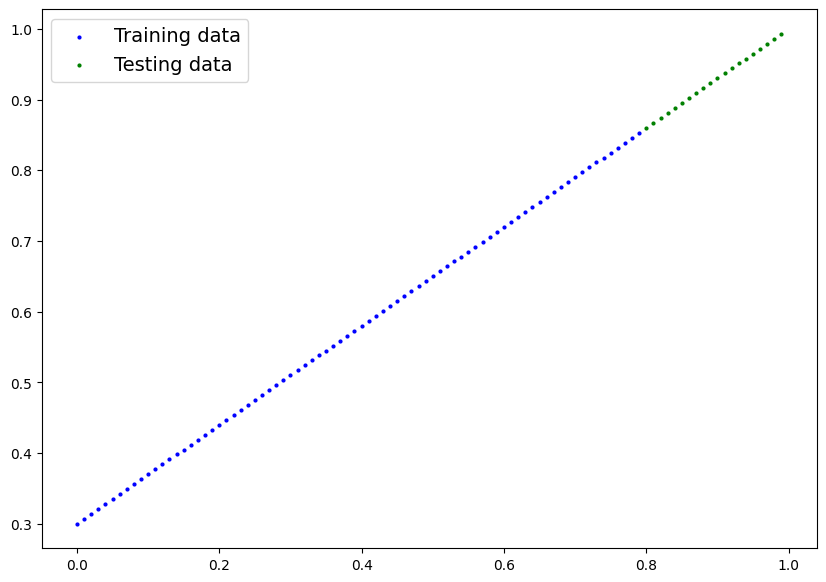

In [36]:
plot_predictions(train_data=X_train_regression,
                 train_labels = y_train_regression,
                 test_data = X_test_regression,
                 test_labels = y_test_regression)

In [37]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [38]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features = 10),
    nn.Linear(in_features=10, out_features = 10),
    nn.Linear(in_features=10, out_features = 1),
).to(device)

In [39]:
loss_fn = nn.L1Loss()

optimiser = torch.optim.SGD(params = model_2.parameters(),
                            lr  = 0.001)

In [40]:
# train the model

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs+1):

  model_2.train()

  y_pred = model_2(X_train_regression)

  loss = loss_fn(y_pred, y_train_regression)

  optimiser.zero_grad()

  loss.backward()

  optimiser.step()

  model_2.eval()

  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  if epoch % 100 == 0:
    print(f'Epoch:{epoch} | loss:{loss:.5f} | Test loss:{test_loss:.5f}')

Epoch:0 | loss:0.75986 | Test loss:0.94965
Epoch:100 | loss:0.40272 | Test loss:0.54029
Epoch:200 | loss:0.05876 | Test loss:0.13480
Epoch:300 | loss:0.01461 | Test loss:0.03342
Epoch:400 | loss:0.00308 | Test loss:0.00008
Epoch:500 | loss:0.00309 | Test loss:0.00012
Epoch:600 | loss:0.00309 | Test loss:0.00018
Epoch:700 | loss:0.00299 | Test loss:0.00011
Epoch:800 | loss:0.00299 | Test loss:0.00016
Epoch:900 | loss:0.00289 | Test loss:0.00011
Epoch:1000 | loss:0.00289 | Test loss:0.00015


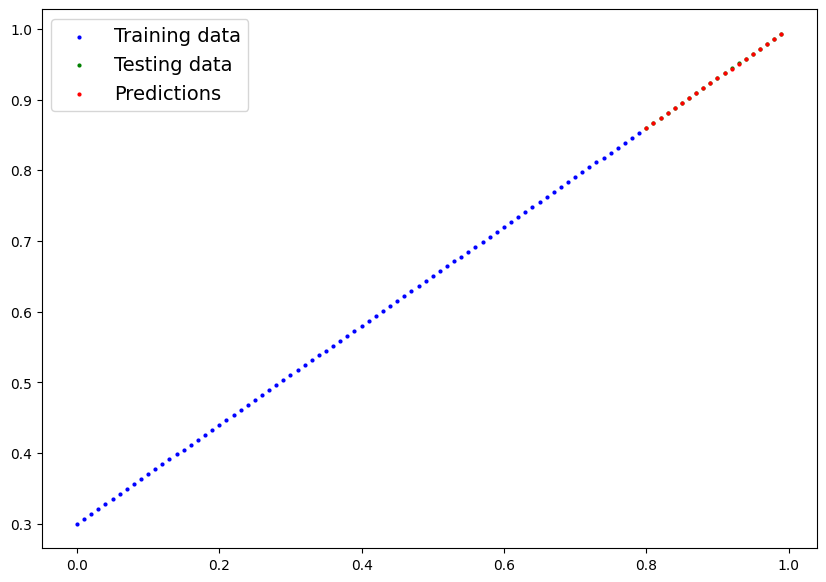

In [41]:
with torch.inference_mode():
  y_regression_pred = model_2(X_test_regression)


plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels = y_train_regression.cpu(),
                 test_data = X_test_regression.cpu(),
                 test_labels = y_test_regression.cpu(),
                 predictions=  y_regression_pred.cpu())

## Non-linearity

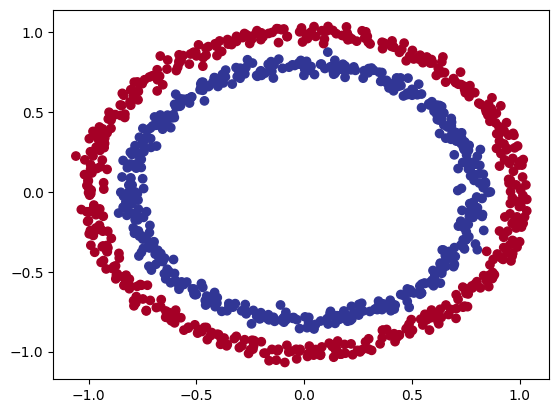

In [42]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap = plt.cm.RdYlBu)

In [43]:
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [44]:
X_train[:5], X_test[:5], y_train[:5], y_test[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438]]),
 tensor([1., 0., 0., 0., 1.]),
 tensor([1., 0., 1., 0., 1.]))

### Building a model with non-linearity

In [45]:
from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
    self.relu = nn.ReLU()


  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))


model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [46]:
loss_fn = nn.BCEWithLogitsLoss()

optimiser = torch.optim.SGD(params = model_3.parameters(),
                            lr = 0.1)

In [47]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_test, X_train = X_test.to(device), X_train.to(device)
y_test, y_train = y_test.to(device), y_train.to(device)

epochs = 2000

for epoch in range(epochs+1):
  model_3.train()

  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  optimiser.zero_grad()

  loss.backward()

  optimiser.step()


  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true=  y_test,
                           y_pred = test_pred)

  if epoch % 100 == 0:
    print(f'Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%')


Epoch: 0 | Loss: 0.69295 | Acc: 50.00% | Test Loss: 0.69319 | Test acc: 50.00%
Epoch: 100 | Loss: 0.69115 | Acc: 52.88% | Test Loss: 0.69102 | Test acc: 52.50%
Epoch: 200 | Loss: 0.68977 | Acc: 53.37% | Test Loss: 0.68940 | Test acc: 55.00%
Epoch: 300 | Loss: 0.68795 | Acc: 53.00% | Test Loss: 0.68723 | Test acc: 56.00%
Epoch: 400 | Loss: 0.68517 | Acc: 52.75% | Test Loss: 0.68411 | Test acc: 56.50%
Epoch: 500 | Loss: 0.68102 | Acc: 52.75% | Test Loss: 0.67941 | Test acc: 56.50%
Epoch: 600 | Loss: 0.67515 | Acc: 54.50% | Test Loss: 0.67285 | Test acc: 56.00%
Epoch: 700 | Loss: 0.66659 | Acc: 58.38% | Test Loss: 0.66322 | Test acc: 59.00%
Epoch: 800 | Loss: 0.65160 | Acc: 64.00% | Test Loss: 0.64757 | Test acc: 67.50%
Epoch: 900 | Loss: 0.62362 | Acc: 74.00% | Test Loss: 0.62145 | Test acc: 79.00%
Epoch: 1000 | Loss: 0.56818 | Acc: 87.75% | Test Loss: 0.57378 | Test acc: 86.50%
Epoch: 1100 | Loss: 0.48153 | Acc: 93.50% | Test Loss: 0.49935 | Test acc: 90.50%
Epoch: 1200 | Loss: 0.37056 

### Evaluationg the model

In [50]:
model_3.eval()

with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

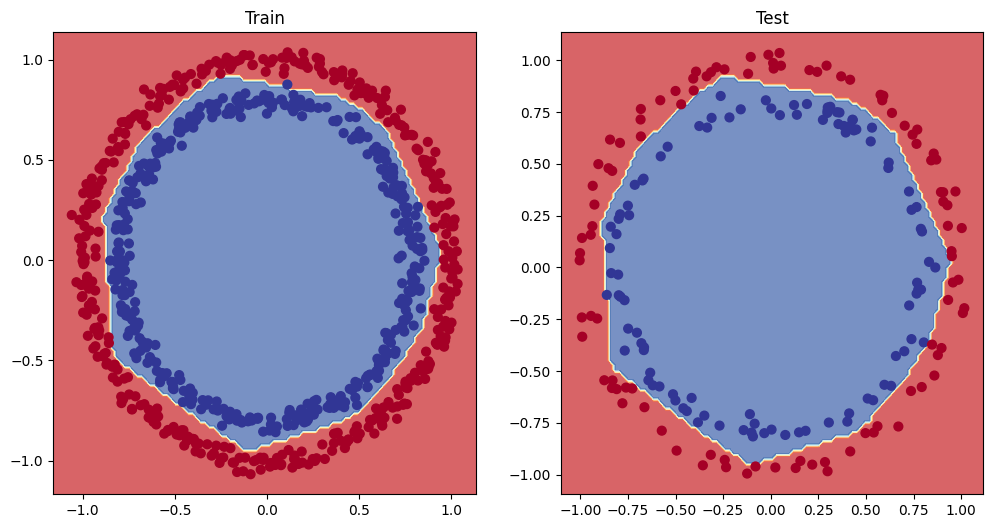

In [51]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test)